In [1]:
# packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
consolidated = pd.read_csv('h251.csv')
prescription = pd.read_csv('h248a.csv')

In [3]:
# merge on patient id
all_data = pd.merge(consolidated, prescription, how="outer", on='DUPERSID')

# select variables for analyis
variables = ['RXSLF23','AGE31X','SEX','RACEV1X','INSCOV23',
             'POVCAT23','REGION23','TC1','DUPERSID','HIBPDX',
             'DIABDX_M18','CHDDX','ASTHDX']

# copy df with selected variables
data = all_data[variables].copy()

# rename columns to identify easier
data.rename(columns={
                  'DUPERSID':'patient_id',
                  'RXSLF23':'out_pocket_payment',
                  'AGE31X':'age',
                  'SEX':'sex',
                  'RACEV1X':'race',
                  'INSCOV23':'insurance_type',
                  'POVCAT23':'income_category',
                  'REGION23':'geographic_region',
                  'TC1':'therapeutic_class',
                  'HIBPDX':'high_bp',
                  'DIABDX_M18':'diabetes',
                  'CHDDX':'heart_disease',
                  'ASTHDX':'asthma',
                  }, inplace=True)

In [4]:
# map 1:yes 0:no for chronic disease
for name in ['high_bp','diabetes','heart_disease','asthma','sex']:
    data[name] = data[name].map(
        lambda x: np.nan if x in [-7,-8,-1] 
        else 0 if x == 2 # for sex this is female
        else 1 if x == 1 
        else np.nan
        )
# map missing payments to nan
data['out_pocket_payment'] = data['out_pocket_payment'].apply(
    lambda x: np.nan if x < 0 
    else x
)

# map races in dataset documentation 
data['race'] = data['race'].map({
    1:'white',
    2:'black/african_american',
    3:'american_indian',
    4:'asian/hawiian/pacific_islander',
    6:'multiple'
    })

# map insurance type in dataset documentation 
data['insurance_type'] = data['insurance_type'].map({
    1:'private',
    2:'public',
    3:'uninsured',
    })

# map income in dataset documentation 
data['income_category'] = data['income_category'].map({
    1:'poor',
    2:'near-poor',
    3:'low',
    4:'middle',
    5:'high'
    })

# remove unknowns 
data = data[data['geographic_region'] != -1]
# map geographic region in dataset documentation 
data['geographic_region'] = data['geographic_region'].map({
    1:'northeast',
    2:'midwest',
    3:'south',
    4:'west'
    })
# Turn therapuetic class into clinical categories
data['therapeutic_class'] = data['therapeutic_class'].map({
    40:  'cardiovascular',   # Cardiovascular Agents
    81:  'cardiovascular',   # Coagulation Modifiers
    358: 'metabolic',        # Metabolic Agents
    97:  'metabolic',        # Hormones/Hormone Modifiers
    218: 'metabolic',        # Alternative Medicines
    57:  'mental_health',    # Central Nervous System Agents
    242: 'mental_health',    # Psychotherapeutic Agents
    122: 'respiratory',      # Respiratory Agents
    1:   'other',            # Anti-Infectives
    87:  'other',            # Gastrointestinal Agents
    133: 'other',            # Topical Agents
    115: 'other',            # Nutritional Products
    113: 'other',            # Genitourinary Tract Agents
    105: 'other',            # Miscellaneous Agents
    20:  'other',            # Antineoplastics
    254: 'other',            # Immunologic Agents
    -15: np.nan              # Not Ascertained
    })

In [5]:
# see where your zeroes are coming from
zero_by_insurance = data.groupby('insurance_type')['out_pocket_payment'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).round(1)

print(zero_by_insurance)

data = data[data['out_pocket_payment'] >0]
data = data[data['age'] >=18]

insurance_type
private       7.7
public       18.7
uninsured    36.3
Name: out_pocket_payment, dtype: float64


<Axes: xlabel='out_pocket_payment', ylabel='Count'>

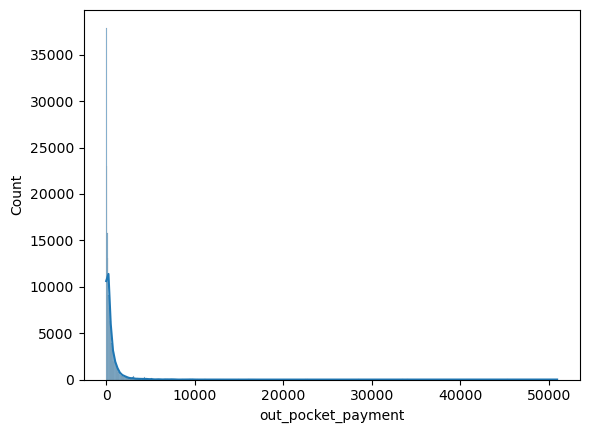

In [6]:
sns.histplot(data['out_pocket_payment'], kde=True)

<Axes: xlabel='out_pocket_payment', ylabel='Count'>

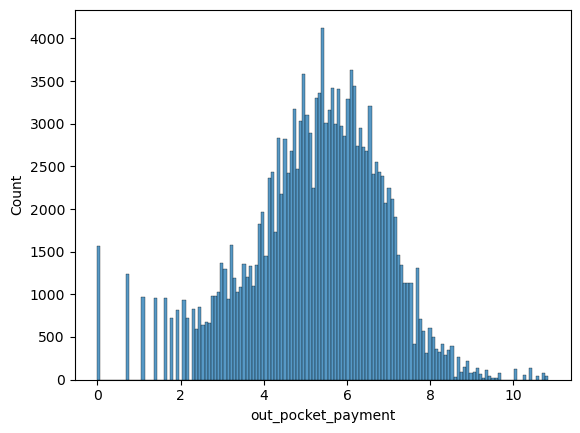

In [7]:
sns.histplot(np.log(data['out_pocket_payment'][data['out_pocket_payment'] >0]))

In [8]:
data['out_pocket_payment'] = np.log(data['out_pocket_payment'])

In [9]:
data.dropna(inplace=True)

In [10]:
data.shape

(161647, 13)

In [11]:
data.to_csv('my_data.csv',index = False)

In [12]:
data = data.set_index('patient_id')

In [13]:
data.sample(n=8, random_state=16).T

patient_id,2791324101,2816674101,2816034101,2798327101,2812081101,2816341102,2797267101,2815772101
out_pocket_payment,5.83773,3.218876,6.624065,6.774224,5.043425,4.553877,4.488636,4.70048
age,60,71,57,74,77,69,63,55
sex,1,0,0,0,1,1,0,0
race,white,black/african_american,white,white,white,asian/hawiian/pacific_islander,black/african_american,white
insurance_type,private,public,public,private,private,public,public,private
income_category,middle,low,low,middle,high,low,poor,near-poor
geographic_region,west,south,northeast,midwest,south,northeast,south,south
therapeutic_class,other,cardiovascular,mental_health,mental_health,metabolic,metabolic,metabolic,metabolic
high_bp,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
diabetes,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [14]:
# out of pocket
print(f'''Mean out of pocket spending is {(round(np.mean(data['out_pocket_payment']),2))}
Standard deviation is {(round(np.std(data['out_pocket_payment']),2))}
''')

# age
print(f'''Mean age is {(round(np.mean(data['age']),2))}
Standard deviation is {(round(np.std(data['age']),2))}
''')

# sex
print(f'''Mean sex is {(round(np.mean(data['sex']),2))}
Standard deviation is {(round(np.std(data['sex']),2))}
''')

# bp
print(f'''Mean bp is {(round(np.mean(data['high_bp']),2))}
Standard deviation is {(round(np.std(data['high_bp']),2))}
''')

# diabetes
print(f'''Mean diabetes is {(round(np.mean(data['diabetes']),2))}
Standard deviation is {(round(np.std(data['diabetes']),2))}
''')

# heart disease
print(f'''Mean heart disease is {(round(np.mean(data['heart_disease']),2))}
Standard deviation is {(round(np.std(data['heart_disease']),2))}
''')

# asthma
print(f'''Mean asthma is {(round(np.mean(data['asthma']),2))}
Standard deviation is {(round(np.std(data['asthma']),2))}
''')

Mean out of pocket spending is 5.21
Standard deviation is 1.67

Mean age is 61.55
Standard deviation is 15.07

Mean sex is 0.41
Standard deviation is 0.49

Mean bp is 0.67
Standard deviation is 0.47

Mean diabetes is 0.32
Standard deviation is 0.47

Mean heart disease is 0.15
Standard deviation is 0.36

Mean asthma is 0.23
Standard deviation is 0.42



In [15]:
print(data['race'].value_counts())
data['race'].value_counts()/sum(data['race'].value_counts())

race
white                             130676
black/african_american             20512
asian/hawiian/pacific_islander      5400
multiple                            3763
american_indian                     1296
Name: count, dtype: int64


race
white                             0.808403
black/african_american            0.126894
asian/hawiian/pacific_islander    0.033406
multiple                          0.023279
american_indian                   0.008017
Name: count, dtype: float64

In [16]:
print(data['insurance_type'].value_counts())
data['insurance_type'].value_counts()/sum(data['insurance_type'].value_counts())

insurance_type
private      84073
public       75683
uninsured     1891
Name: count, dtype: int64


insurance_type
private      0.520102
public       0.468199
uninsured    0.011698
Name: count, dtype: float64

In [17]:
print(data['income_category'].value_counts())
data['income_category'].value_counts()/sum(data['income_category'].value_counts())

income_category
high         61419
middle       41526
poor         27749
low          21745
near-poor     9208
Name: count, dtype: int64


income_category
high         0.379958
middle       0.256893
poor         0.171664
low          0.134522
near-poor    0.056964
Name: count, dtype: float64

In [18]:
print(data['geographic_region'].value_counts())
data['geographic_region'].value_counts()/sum(data['geographic_region'].value_counts())

geographic_region
south        62713
midwest      38787
west         32386
northeast    27761
Name: count, dtype: int64


geographic_region
south        0.387963
midwest      0.239949
west         0.200350
northeast    0.171738
Name: count, dtype: float64

In [19]:
print(data['therapeutic_class'].value_counts())
data['therapeutic_class'].value_counts()/sum(data['therapeutic_class'].value_counts())

therapeutic_class
mental_health     41733
metabolic         41164
cardiovascular    36254
other             33235
respiratory        9261
Name: count, dtype: int64


therapeutic_class
mental_health     0.258174
metabolic         0.254654
cardiovascular    0.224279
other             0.205602
respiratory       0.057292
Name: count, dtype: float64